In [1]:
import os as os
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 

In [8]:
path_to_raw = "/home/matias/Documents/ML-libs/raw_data"
#path_to_raw = "/home/redmati/Documents/ML-LIBS/raw_data"

cwd = os.getcwd()

In [222]:
list_of_experiments= os.listdir(path_to_raw)
print(f"The experiments available are:\n")
for i in list_of_experiments:print(i)

The experiments available are:

F1-muestra 1-log_09ago.24_111305-ascii
N1-Muestra 1-log_24jul.24_161346-ascii


### Choose the set of experiments to condensate 

In [6]:
# Choose a discrete set of experiments :
dat_to_con = ["F1-muestra 1-log_09ago.24_111305-ascii",
              "N1-Muestra 1-log_24jul.24_161346-ascii"]

# Or the whole set of experiments: 
#data_to_con = list_of_experiments

In [16]:
def get_experiemnts(path_to_raw, show=False):
    """Get the list of experiment in a path 
    path_to_raw= Path to files 
    show = print list of experiments 
    """
    list_of_experiments= os.listdir(path_to_raw)
    if show == True:
        print (list_of_experiments)

    return list_of_experiments


def get_idx(experiment, seg): 
    """ get indexes of files with the desired part of the spectrum 
        for a single experiment. 
        experiment = path to experiment folder 
        seg = segment of spectrum : Merge0 or name of spectrometer
        return list of index and name of files in experiment """
    
    # Move to experiment folder and get list of files
    os.chdir(f"{path_to_raw}/{experiment}/")
    listOffile = os.listdir()
    # get indexes of files with the desired part of the spectrum.: 
    idx =[]
    idx = [i for i, file in enumerate(listOffile) if seg in file]
    return idx,listOffile


def condense(dat_to_con, seg, test=False):
    """ This function takes a list of experiments and condense all 
    the spectra of that experiment in a single csv.
    data_to_con= list of experiments 
    seg = segment of the spectrum or Merge0
    test = Flag to return the last csv as DataFram
    """
    for experiment in dat_to_con:
        idx, listOffile = get_idx(experiment, seg)
        os.chdir(f"{path_to_raw}/{experiment}")
        print(os.getcwd())
        for i,index in enumerate(idx):
            data = pd.read_csv(listOffile[index], delimiter=";", skiprows=2, header=None)
            data.replace(',', '.', regex=True, inplace=True)
            data = data.astype(float)
            ## Drop duplicated wavelenght, if there are:
            data.drop_duplicates(subset=0, keep="first", inplace=True)


            if i==0 : # Add wavelenght as column names : 
                condense_data = pd.DataFrame(columns=data.iloc[:,0])

            condense_data.loc[i]= np.asanyarray(data.iloc[:,1])

        files = [listOffile[j] for j in idx] 
        condense_data["file"] = files 
        condense_data["experiment"] = experiment   

        os.makedirs("condensate", exist_ok=True)
        condense_data.to_csv(f"./condensate/{experiment}_{seg}_condense.csv")

    if test == True: 
        return data, condense_data         
    
     
def join_data(path_to_raw, dat_to_con, seg):
    """Join the condensed data form multiple experiments
    path_to_raw= Path to files
    seg = segment of the spectrum or Merge0
    data_to_con= list of experiments needed for the model, 
    tipically, 2 different experiments 
    return join df
    """ 
    
    os.chdir(path_to_raw)
    dfs = {}
    for i, experiment in enumerate(dat_to_con,1):
        dfs[f'df{i}'] = pd.read_csv(f"{experiment}/condensate/{experiment}_{seg}_condense.csv")

    df_final = pd.concat(dfs.values(), ignore_index=True)
    df_final.drop(columns="Unnamed: 0", inplace=True)

    #Change column names to float (ugly approach):
    columns_to_keep_as_strings = ['file', 'experiment']

    # Create a new dictionary for renaming columns
    new_column_names = {}
    for col in df_final.columns:
        if col not in columns_to_keep_as_strings:
            # Convert column name to float if it's not in the keep list
            new_column_names[col]= float(col)
        else:
            # Keep the original name for specified columns
            new_column_names[col]= col

    # Rename the columns in the DataFrame
    df_final.rename(columns=new_column_names, inplace=True)

    return df_final


 
    




In [229]:
experiment = dat_to_con[0]
idx,listOffile = get_idx(experiment,seg)

In [14]:
dat_to_con

['F1-muestra 1-log_09ago.24_111305-ascii',
 'N1-Muestra 1-log_24jul.24_161346-ascii']

In [29]:
seg = "Merge0" # part of the spectrum; "Merge_0" or name of spectrometer
data, condense_data = condense(dat_to_con, seg, test=True)
#condense(dat_to_con, seg, test=False)

/home/matias/Documents/ML-libs/raw_data/F1-muestra 1-log_09ago.24_111305-ascii
/home/matias/Documents/ML-libs/raw_data/N1-Muestra 1-log_24jul.24_161346-ascii


In [35]:
for i in condense_data.columns:print(i)

211.53
211.62
211.72
211.81
211.91
212.0
212.09
212.19
212.28
212.38
212.47
212.56
212.66
212.75
212.85
212.94
213.04
213.13
213.22
213.32
213.41
213.51
213.6
213.69
213.79
213.88
213.98
214.07
214.16
214.26
214.35
214.45
214.54
214.63
214.73
214.82
214.91
215.01
215.1
215.2
215.29
215.38
215.48
215.57
215.67
215.76
215.85
215.95
216.04
216.13
216.23
216.32
216.42
216.51
216.6
216.7
216.79
216.89
216.98
217.07
217.17
217.26
217.35
217.45
217.54
217.63
217.73
217.82
217.92
218.01
218.1
218.2
218.29
218.38
218.48
218.57
218.66
218.76
218.85
218.95
219.04
219.13
219.23
219.32
219.41
219.51
219.6
219.69
219.79
219.88
219.97
220.07
220.16
220.25
220.35
220.44
220.53
220.63
220.72
220.81
220.91
221.0
221.1
221.19
221.28
221.38
221.47
221.56
221.66
221.75
221.84
221.94
222.03
222.12
222.22
222.31
222.4
222.49
222.59
222.68
222.77
222.87
222.96
223.05
223.15
223.24
223.33
223.43
223.52
223.61
223.71
223.8
223.89
223.99
224.08
224.17
224.27
224.36
224.45
224.54
224.64
224.73
224.82
224.92
225.0

In [33]:
condense_data.columns

Index([      211.53,       211.62,       211.72,       211.81,       211.91,
              212.0,       212.09,       212.19,       212.28,       212.38,
       ...
             636.61,       636.66,       636.71,       636.75,        636.8,
             636.85,        636.9,       636.94,       'file', 'experiment'],
      dtype='object', name=0, length=6146)

ValueError: Unable to parse string "log161450315_Merge0.TXT" at position 6144

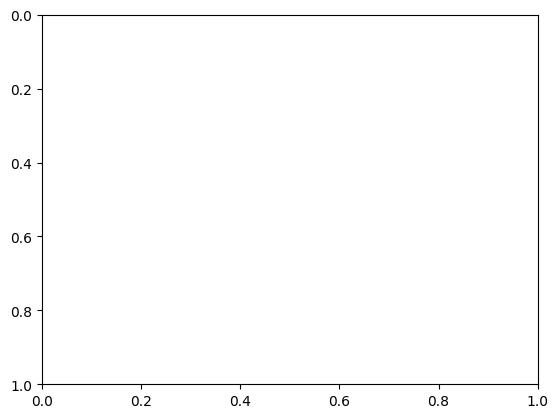

In [31]:
sns.lineplot(x=condense_data.columns, y=condense_data.loc[2])

In [17]:
df = join_data(path_to_raw, dat_to_con, seg="Merge0")

In [19]:
df

,211.53,211.62,211.72,211.81,211.91,212.0,212.09,212.19,212.28,212.38,...,636.61,636.66,636.71,636.75,636.8,636.85,636.9,636.94,file,experiment
0,202.05000,194.05000,210.05000,196.05000,169.05000,245.05000,201.05000,211.05000,228.05000,258.04999,...,370.64999,388.64999,385.64999,397.64999,394.64999,392.64999,409.64999,406.64999,log111441808_Merge0.TXT,F1-muestra 1-log_09ago.24_111305-ascii
1,240.30000,232.30000,213.30000,247.30000,219.30000,238.30000,182.30000,233.30000,216.30000,216.30000,...,364.82501,363.82501,373.82501,363.82501,381.82501,403.82501,410.82501,399.82501,log111356925_Merge0.TXT,F1-muestra 1-log_09ago.24_111305-ascii
2,188.27499,250.27499,217.27499,194.27499,202.27499,266.27499,219.27499,215.27499,219.27499,233.27499,...,368.95001,421.95001,386.95001,372.95001,396.95001,401.95001,407.95001,402.95001,log111525098_Merge0.TXT,F1-muestra 1-log_09ago.24_111305-ascii
3,201.17500,241.17500,232.17500,238.17500,191.17500,216.17500,222.17500,231.17500,198.17500,213.17500,...,381.50000,440.50000,355.50000,380.50000,385.50000,424.50000,399.50000,373.50000,log111406545_Merge0.TXT,F1-muestra 1-log_09ago.24_111305-ascii
4,201.87500,232.87500,233.87500,209.87500,181.87500,242.87500,207.87500,210.87500,250.87500,214.87500,...,375.12500,393.12500,372.12500,403.12500,390.12500,403.12500,406.12500,413.12500,log111425781_Merge0.TXT,F1-muestra 1-log_09ago.24_111305-ascii
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,216.70000,269.70001,227.70000,214.70000,199.70000,270.70001,236.70000,223.70000,223.70000,221.70000,...,372.42499,386.42499,356.42499,375.42499,386.42499,413.42499,426.42499,385.42499,log161350999_Merge0.TXT,N1-Muestra 1-log_24jul.24_161346-ascii
196,206.60001,271.60001,252.60001,245.60001,196.60001,247.60001,213.60001,248.60001,204.60001,232.60001,...,364.07501,397.07501,346.07501,413.07501,389.07501,377.07501,415.07501,364.07501,log161544821_Merge0.TXT,N1-Muestra 1-log_24jul.24_161346-ascii
197,239.92500,242.92500,250.92500,232.92500,198.92500,257.92499,234.92500,222.92500,209.92500,224.92500,...,362.52499,421.52499,383.52499,374.52499,397.52499,407.52499,435.52499,396.52499,log161531997_Merge0.TXT,N1-Muestra 1-log_24jul.24_161346-ascii
198,223.75000,219.75000,235.75000,245.75000,221.75000,233.75000,193.75000,253.75000,222.75000,214.75000,...,375.72501,413.72501,404.72501,374.72501,399.72501,445.72501,410.72501,389.72501,log161548028_Merge0.TXT,N1-Muestra 1-log_24jul.24_161346-ascii
